# Sidequest - Polynomial Regression

This is a side quest for the lab 05 on jan 30. The task was to implement a polynomial regressor from scratch

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

## `PolynomialRegressor` class

In [108]:
class PolynomialRegressor:
    def __init__(self, max_degree, max_iter=1000):
        self.max_degree = max_degree
        self.max_iter = max_iter
        self.weights = None
        self.X_poly = None
        pass

    def fit(self, X: pd.DataFrame, y: pd.DataFrame, learning_rate=0.01):
        num_samples = len(X)
        y = np.array(y).flatten()
        if (len(y) != num_samples):
            print(f"Invalid Shape")
            return
        for _ in range(self.max_iter):
            y_pred = self.predict(X, test=False)
            mse = np.square(np.subtract(y, y_pred))
            gradients = np.array((2 / num_samples) * np.dot(self.X_poly.T, mse)).flatten()
            self.weights = np.subtract(self.weights, learning_rate * gradients)

    def predict(self, X: pd.DataFrame, test = True):
        num_samples = len(X)
        X_poly = X
        if self.X_poly is None:
            for column in X.columns:
                for degree in range(2, self.max_degree + 1):
                    X_poly[f"{column}^{degree}"] = X_poly[column] ** degree
            X_poly["coefficient of 1"] = [1] * num_samples
            X_poly = np.array(X_poly)
            self.X_poly = X_poly
        if self.weights is None:
            self.weights = np.array([0] * len(X_poly[0]))
        if test:
            X_poly = X
            for column in X.columns:
                for degree in range(2, self.max_degree + 1):
                    X_poly[f"{column}^{degree}"] = X_poly[column] ** degree
            X_poly["coefficient of 1"] = [1] * num_samples
            X_poly = np.array(X_poly)
            y_pred = np.dot(X_poly, self.weights)
        else:
            y_pred = np.dot(self.X_poly, self.weights)
        return np.array(y_pred).flatten()
    
    def evaluate(self, X: pd.DataFrame, y_true = pd.DataFrame):
        num_samples = len(X, test=False)
        y_true = np.array(y_true)
        if (len(y_true) != num_samples):
            print(f"Invalid Shape")
            return
        y_pred = self.predict(X)
        return mean_absolute_error(y_true, y_pred), mean_squared_error(y_true, y_pred)


## Generate Random Data

Let's generate a random data to test the `PolynomialRegressor` of degree 2.

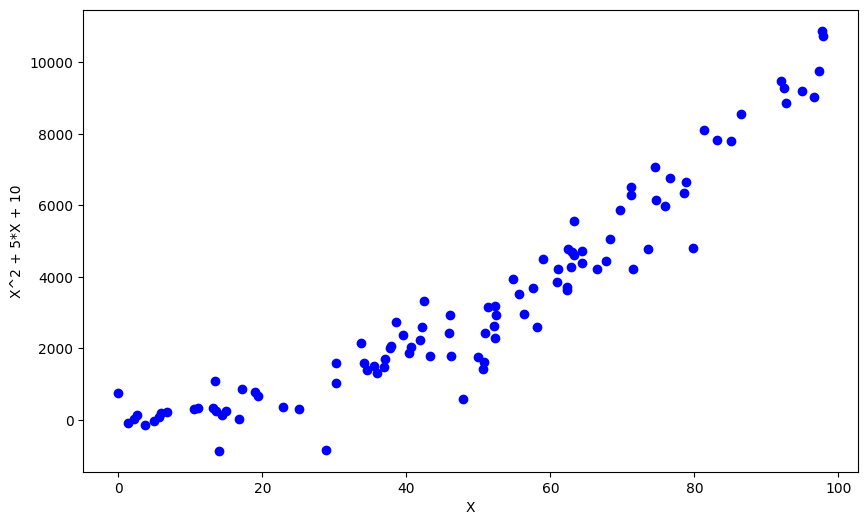

In [103]:
num_samples = 100
X = np.random.uniform(0, 100, num_samples)
y = X ** 2 + 5 * X + 10
y_noise = np.random.normal(0, 100, num_samples) * 7
y = np.add(y, y_noise)

plt.figure(figsize=(10, 6))
plt.plot(X, y, "ob")
plt.xlabel("X")
plt.ylabel("X^2 + 5*X + 10")
plt.show()

## Usage

In [109]:
X = pd.DataFrame(X)
y = pd.DataFrame(y)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)
model = PolynomialRegressor(max_degree=2)
model.fit(X_train, y_train)

C:\Users\ujjwa\AppData\Local\Temp\ipykernel_32496\146245550.py:17: RuntimeWarning: overflow encountered in square
  mse = np.square(np.subtract(y, y_pred))


In [110]:
x = np.linspace(X.min(), X.max(), num=50)
ys = model.predict(pd.DataFrame(x))
ys

array([-inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf,
       -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf,
       -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf,
       -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf, -inf,
       -inf, -inf, -inf, -inf, -inf, -inf])